In [61]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import convnext_tiny
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
import seaborn as sns
import librosa


In [62]:
# Paramètres audio
SR           = 22050      # Sample rate cible (Hz)
TARGET_LEN   = SR * 6     # Durée fixe : 6 secondes = 132 300 samples
MIN_DURATION = 4.0        # Drop fichiers < 4 secondes

# Filtrage bandpass 
BANDPASS_LOW  = 100       # Hz — coupe bruits mécaniques (stéthoscope, mouvements)
BANDPASS_HIGH = 2000      # Hz — coupe bruits parasites hautes fréquences

# Spectrogramme Mel 
N_MELS     = 224          # Valeur de base 128
N_FFT      = 2048
HOP_LENGTH = 590          # Valeur de base 512

# Features acoustiques 
N_MFCC = 13

# Sorties 
PROCESSED_DIR = '../data/processed'

def compute_mel_spectrogram(audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    return librosa.power_to_db(mel, ref=np.max)

In [63]:
# Import du dataset numpy
directory = "C:/Users/lrozier/Documents/UQAC/respiratory-disease-detection/data/processed/"
X_features = np.load(directory + "X_features.npy")
X = np.load(directory + "X.npy")
y = np.load(directory + "y.npy")

print("Forme de X_features :", X_features.shape)
print("Forme de X :", X.shape)
print("Forme de y :", y.shape)

Forme de X_features : (1201, 16)
Forme de X : (1201, 132300)
Forme de y : (1201,)


In [64]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

for i, class_name in enumerate(le.classes_):
    print(f"Classe {i} : {class_name}")

Classe 0 : asthma
Classe 1 : bronchial
Classe 2 : copd
Classe 3 : healthy
Classe 4 : pneumonia


In [65]:
# Split en train, validation et test
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(split1.split(X, y_encoded))

X_train, X_temp = X[train_idx], X[temp_idx]
y_train, y_temp = y_encoded[train_idx], y_encoded[temp_idx]

split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(split2.split(X_temp, y_temp))

X_val, X_test = X_temp[val_idx], X_temp[test_idx]
y_val, y_test = y_temp[val_idx], y_temp[test_idx]

In [66]:
# Augmentation de données : bruit gaussien, time-shift, pitch shift, SpecAugment

X_train_augmented = []
y_train_augmented = []

for x, label in zip(X_train, y_train):
    # Original
    X_train_augmented.append(x)
    y_train_augmented.append(label)
    
    # Bruit gaussien
    noise = np.random.normal(0, 0.005, x.shape)
    X_train_augmented.append(x + noise)
    y_train_augmented.append(label)
    
    # Time-shift
    shift = np.random.randint(-1000, 1000)
    X_train_augmented.append(np.roll(x, shift))
    y_train_augmented.append(label)
    
    # Pitch shift
    pitch_shifted = librosa.effects.pitch_shift(x, sr=SR, n_steps=np.random.uniform(-2, 2))
    X_train_augmented.append(pitch_shifted)
    y_train_augmented.append(label)               

In [67]:
# Calcul des spectrogrammes Mel pour chaque ensemble
X_train = np.array([compute_mel_spectrogram(audio) for audio in X_train_augmented])
y_train = np.array(y_train_augmented)
X_val = np.array([compute_mel_spectrogram(audio) for audio in X_val])
X_test = np.array([compute_mel_spectrogram(audio) for audio in X_test])

In [68]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) if X_train.ndim == 3 else torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1) if X_val.ndim == 3 else torch.tensor(X_val, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_t, torch.tensor(y_train, dtype=torch.long)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, torch.tensor(y_val, dtype=torch.long)), batch_size=64)


device = "cuda" if torch.cuda.is_available() else "cpu"
model = convnext_tiny(pretrained=True)

# Adaptation de l'entrée (3 canaux -> 1 canal)
first_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(1, first_conv.out_channels, kernel_size=4, stride=4)
with torch.no_grad():
    model.features[0][0].weight.data = first_conv.weight.data.mean(dim=1, keepdim=True)


# Adaptation de la sortie (5 classes)
model.classifier = nn.Sequential(
    nn.Flatten(1),
    nn.LayerNorm((768,), eps=1e-6, elementwise_affine=True),
    nn.Flatten(1),
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 5)
)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-6)

print(f"Début de l'entraînement sur : {torch.cuda.get_device_name(0)}")


#for param in model.parameters():
#    param.requires_grad = True

for epoch in range(10):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    print(f"Epoch {epoch+1}/10, Loss: {loss.item():.4f}")

c:\Users\lrozier\Documents\UQAC\respiratory-disease-detection\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lrozier\Documents\UQAC\respiratory-disease-detection\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Début de l'entraînement sur : NVIDIA GeForce RTX 4070 SUPER
Epoch 1/10, Loss: 1.5591
Epoch 2/10, Loss: 1.0053
Epoch 3/10, Loss: 0.6688
Epoch 4/10, Loss: 0.3300
Epoch 5/10, Loss: 0.0318
Epoch 6/10, Loss: 0.1064
Epoch 7/10, Loss: 0.0376
Epoch 8/10, Loss: 0.0722
Epoch 9/10, Loss: 0.0128
Epoch 10/10, Loss: 0.0046


ÉVALUATION DU MODÈLE

Accuracy globale:        0.9171
Macro F1-score:          0.8919  <- Métrique clé
Weighted F1-score:       0.9159

RAPPORT DE CLASSIFICATION PAR CLASSE

(Sensibilité = Recall = % de vrais positifs détectés par classe)
              precision    recall  f1-score   support

      asthma     0.9091    0.9302    0.9195        43
   bronchial     0.9231    0.8000    0.8571        15
        copd     0.9508    0.9508    0.9508        61
     healthy     0.8333    0.7500    0.7895        20
   pneumonia     0.9111    0.9762    0.9425        42

    accuracy                         0.9171       181
   macro avg     0.9055    0.8814    0.8919       181
weighted avg     0.9164    0.9171    0.9159       181



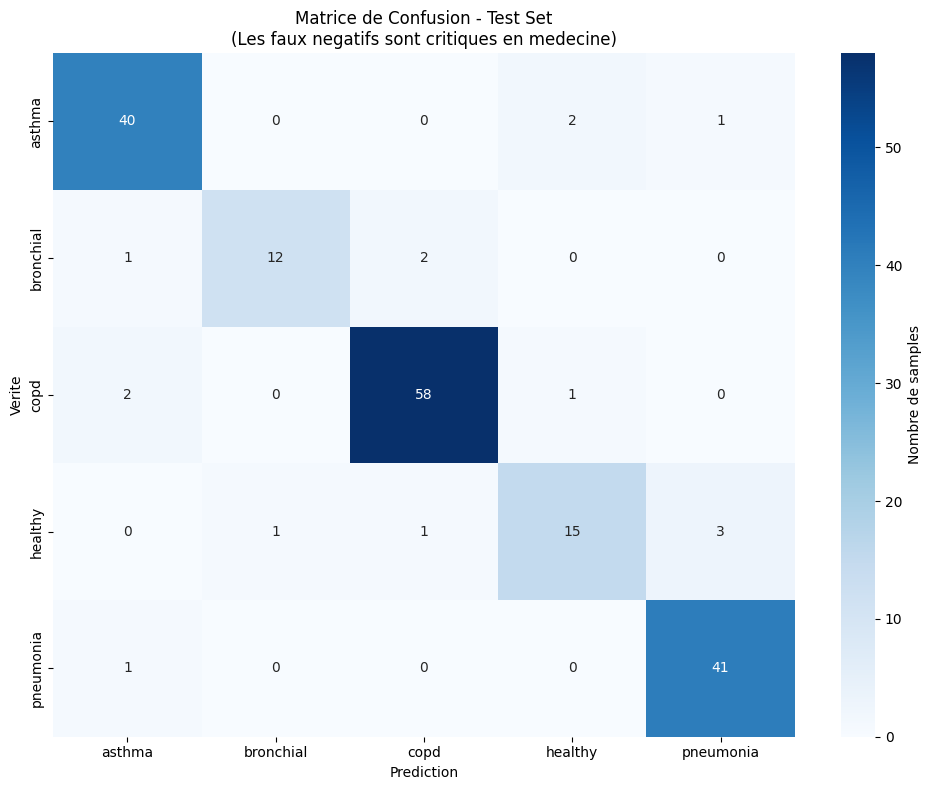


ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE
asthma         : FN=  3, TP= 40, Sensibilite=0.9302
bronchial      : FN=  3, TP= 12, Sensibilite=0.8000
copd           : FN=  3, TP= 58, Sensibilite=0.9508
healthy        : FN=  5, TP= 15, Sensibilite=0.7500
pneumonia      : FN=  1, TP= 41, Sensibilite=0.9762

AUC-ROC PAR CLASSE
asthma         : AUC-ROC = 0.9901
bronchial      : AUC-ROC = 0.9831
copd           : AUC-ROC = 0.9934
healthy        : AUC-ROC = 0.9842
pneumonia      : AUC-ROC = 0.9962

Moyenne AUC-ROC: 0.9894


In [72]:
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1) if X_test.ndim == 3 else torch.tensor(X_test, dtype=torch.float32)
test_loader = DataLoader(TensorDataset(X_test_t, torch.tensor(y_test, dtype=torch.long)), batch_size=64, shuffle=False)


# Faire les prédictions sur le test set
model.eval()
y_test_pred = []
y_test_proba = []

with torch.no_grad():
    for specs, labels in test_loader:
        specs = specs.to(device, non_blocking=True)
        with torch.amp.autocast(device):
            outputs = model(specs)
        proba = torch.nn.functional.softmax(outputs, dim=1)
        y_test_pred.extend(outputs.argmax(dim=1).cpu().numpy())
        y_test_proba.extend(proba.cpu().numpy())

y_test_pred = np.array(y_test_pred)
y_test_proba = np.array(y_test_proba)

print("="*70)
print("ÉVALUATION DU MODÈLE")
print("="*70)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAccuracy globale:        {accuracy:.4f}")
print(f"Macro F1-score:          {macro_f1:.4f}  <- Métrique clé")
print(f"Weighted F1-score:       {weighted_f1:.4f}")

print("\n" + "="*70)
print("RAPPORT DE CLASSIFICATION PAR CLASSE")
print("="*70)
print("\n(Sensibilité = Recall = % de vrais positifs détectés par classe)")
print(classification_report(y_test, y_test_pred,
                          target_names=le.classes_,
                          digits=4,
                          zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre de samples'}, ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Verite')
ax.set_title('Matrice de Confusion - Test Set\n(Les faux negatifs sont critiques en medecine)')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE")
print("="*70)
for i, class_name in enumerate(le.classes_):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    sensibilite = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"{class_name:15s}: FN={fn:3d}, TP={tp:3d}, Sensibilite={sensibilite:.4f}")

print("\n" + "="*70)
print("AUC-ROC PAR CLASSE")
print("="*70)

y_test_onehot = np.eye(len(le.classes_))[y_test]

auc_scores = []
for i, class_name in enumerate(le.classes_):
    try:
        auc_score = roc_auc_score(y_test_onehot[:, i], y_test_proba[:, i])
        auc_scores.append(auc_score)
        print(f"{class_name:15s}: AUC-ROC = {auc_score:.4f}")
    except Exception:
        print(f"{class_name:15s}: AUC-ROC = N/A (classe insuffisante)")

mean_auc = np.mean(auc_scores) if auc_scores else 0
print(f"\nMoyenne AUC-ROC: {mean_auc:.4f}")

Nombre total d'erreurs : 15


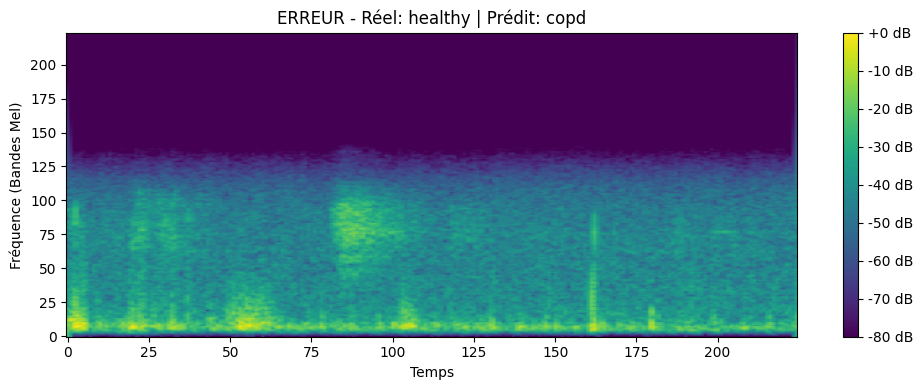

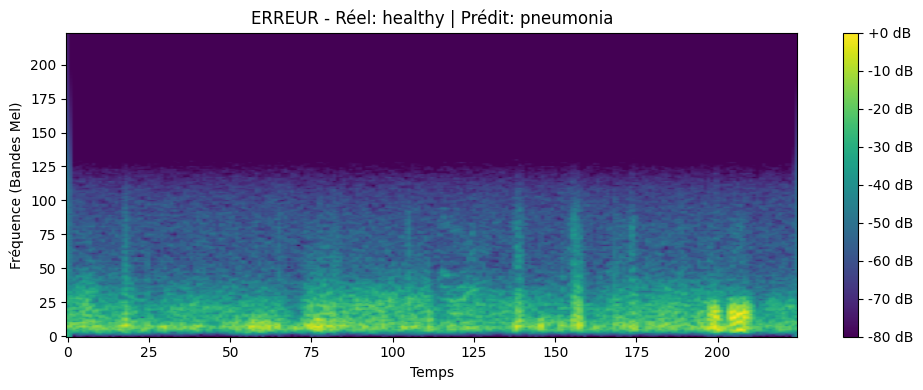

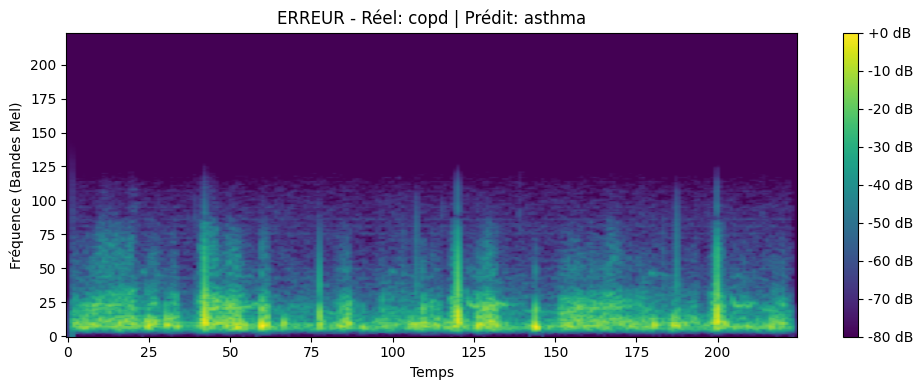

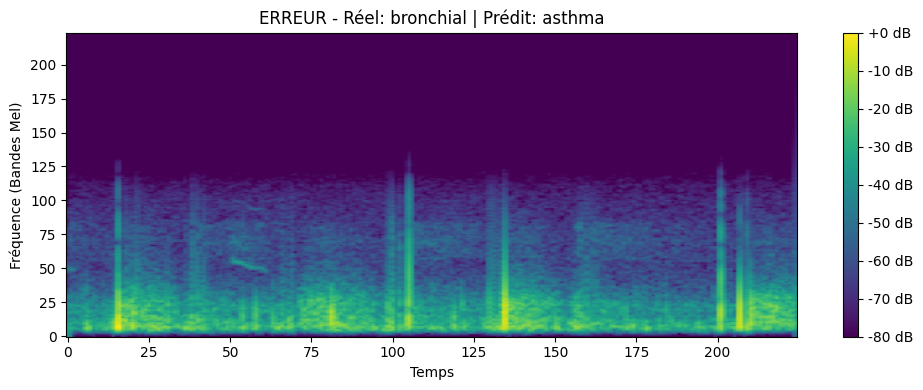

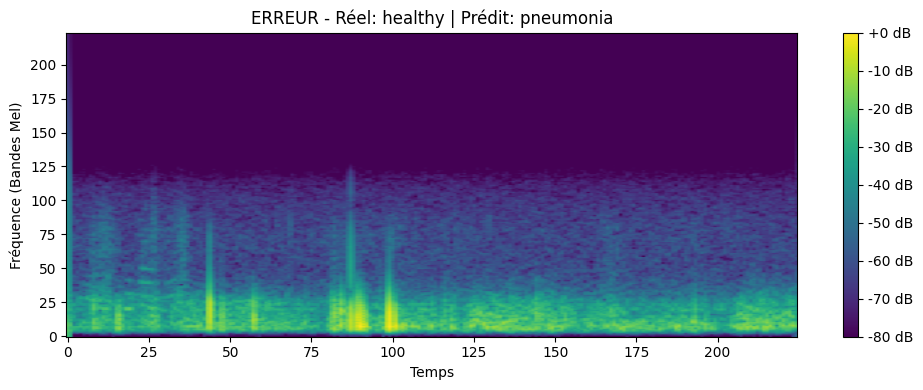

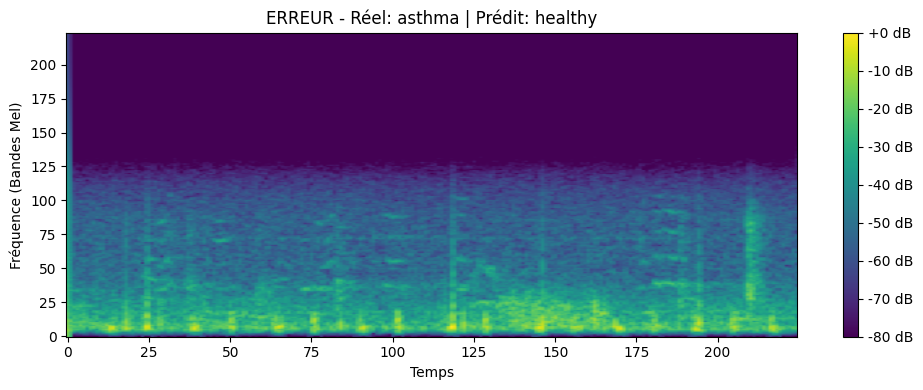

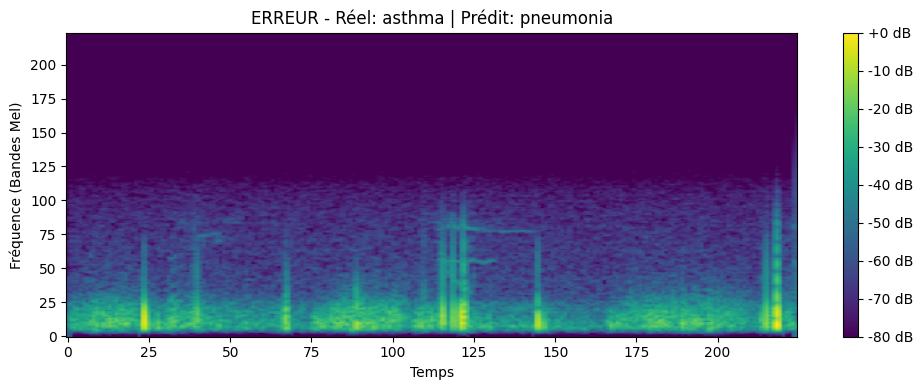

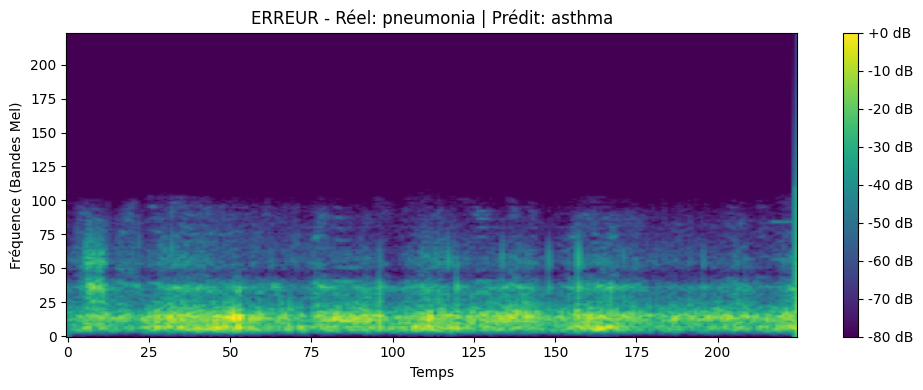

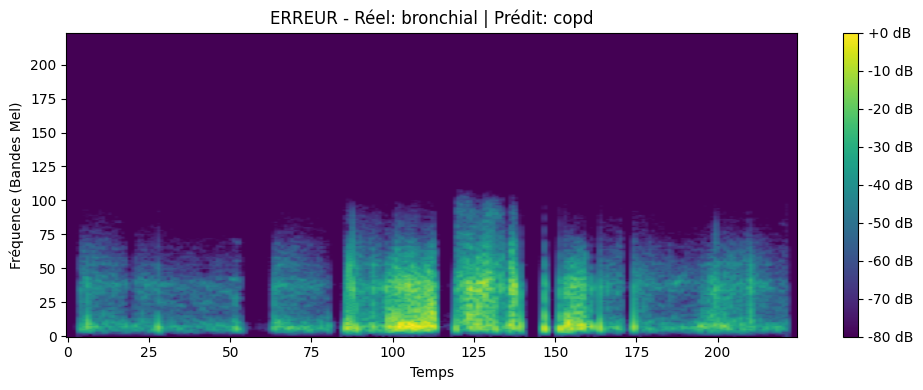

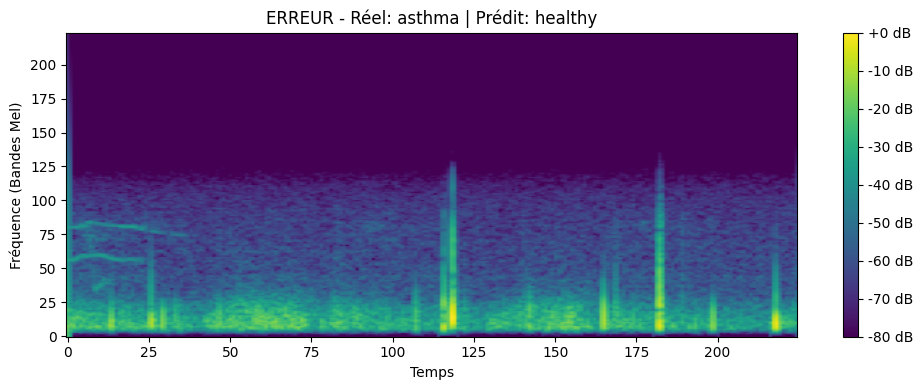

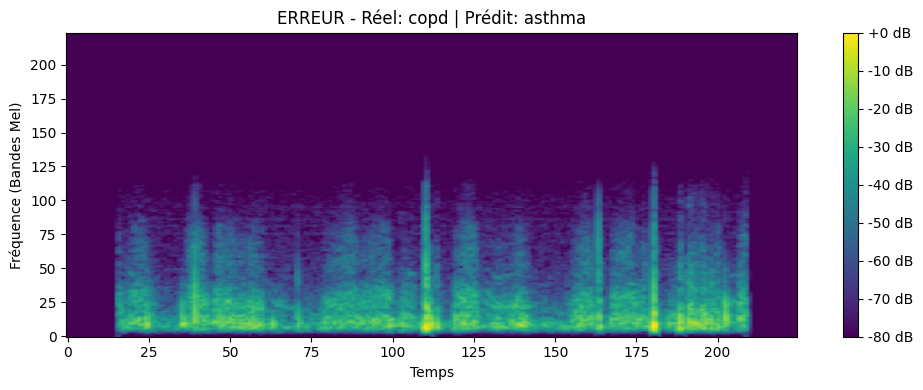

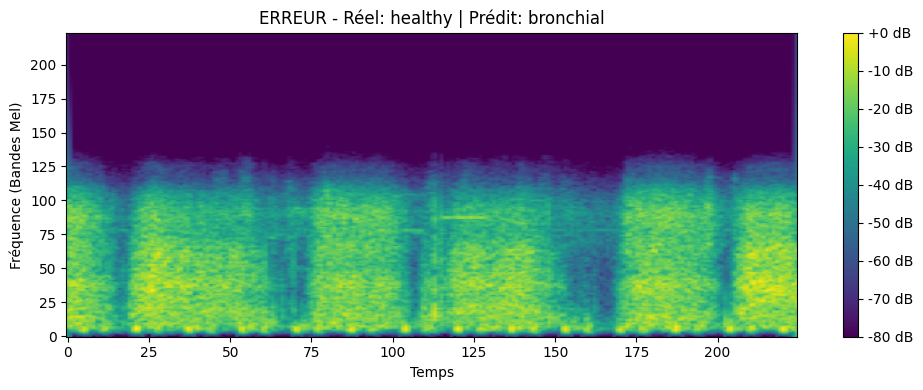

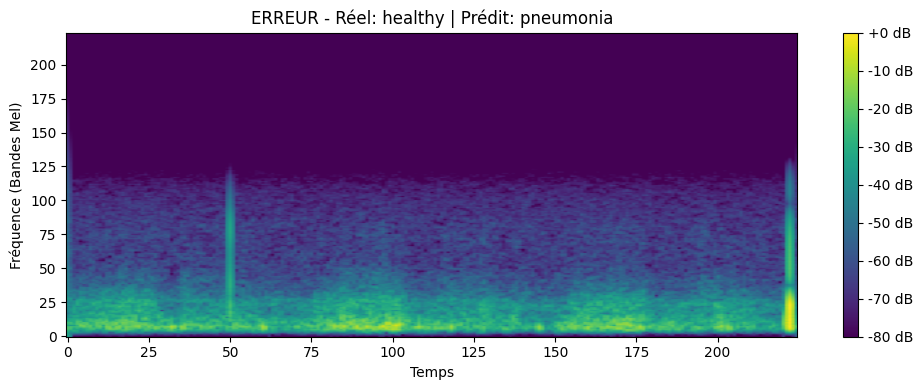

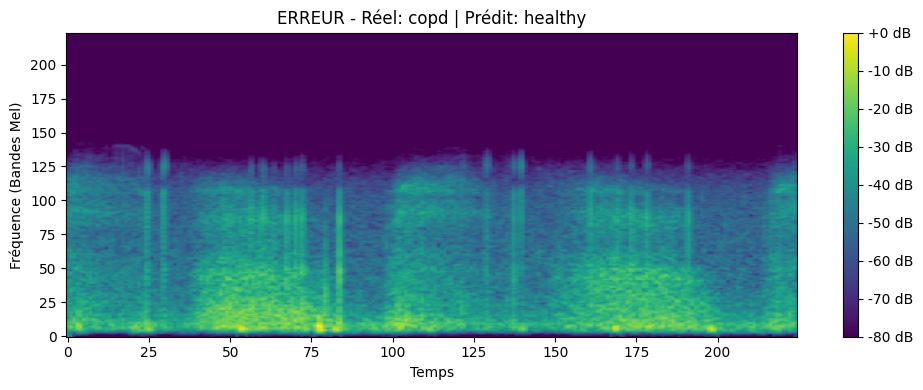

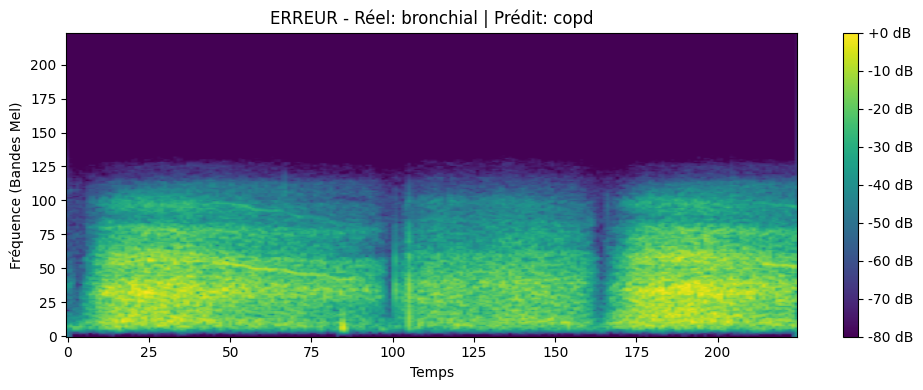

In [70]:
# Masque des erreurs (indices où la prédiction est différente de la réalité)
errors_indices = np.where(y_test != y_test_pred)[0]

print(f"Nombre total d'erreurs : {len(errors_indices)}")

for idx in errors_indices[:]:
    plt.figure(figsize=(10, 4))
    
    # On affiche le spectrogramme original (X_test[idx])
    plt.imshow(X_test[idx], aspect='auto', origin='lower', cmap='viridis')
    
    real_class = le.classes_[y_test[idx]]
    pred_class = le.classes_[y_test_pred[idx]]
    
    plt.title(f"ERREUR - Réel: {real_class} | Prédit: {pred_class}")
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Temps')
    plt.ylabel('Fréquence (Bandes Mel)')
    plt.tight_layout()
    plt.show()